# Week 4 Text Robustness Evaluation

Reproducible view of the frozen 35-scenario, three-model paraphrase experiment and the 14-scenario masked-input experiment. Raw prompts, outputs, and AI-assisted row scores remain in the private experiment archive; this notebook consumes submission-safe aggregate evidence. Scores are diagnostic because the local Judge did not pass calibration.

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'W04_Robustness_Summary_v0.1.0.json').exists():
    ROOT = Path.cwd() / 'phase_b_evaluation'
summary = json.loads((ROOT / 'W04_Robustness_Summary_v0.1.0.json').read_text(encoding='utf-8'))
assert summary['model_count'] == 3
summary['interpretation_boundary']

'Semantic consistency and masked curves use an uncalibrated AI-assisted rubric score. They are diagnostic benchmark evidence, not deployed-product claims.'

In [2]:
semantic_rows = []
mask_rows = []
for model in summary['models']:
    semantic_rows.append({
        'model': model['candidate_model_key'],
        'semantic_robustness': model['semantic_robustness']['semantic_robustness_score'],
        'stable_pass': model['semantic_robustness']['stable_pass_scenario_count'],
        'stable_fail': model['semantic_robustness']['stable_fail_scenario_count'],
        'review_flags': model['mandatory_review_count'],
    })
    for point in model['masked_input']['curves']:
        mask_rows.append({'model': model['candidate_model_key'], **point})
semantic_df = pd.DataFrame(semantic_rows)
mask_df = pd.DataFrame(mask_rows)
display(semantic_df)
display(mask_df[['model', 'mask_ratio', 'mean_task_accuracy', 'pass_rate', 'severity_5_failure_count']])

,model,semantic_robustness,stable_pass,stable_fail,review_flags
0,flan_t5_base,0.914286,7,25,5
1,llama31_8b_instruct,0.857143,26,4,12
2,mistral_7b_instruct_v0_2,0.857143,30,0,9


,model,mask_ratio,mean_task_accuracy,pass_rate,severity_5_failure_count
0,flan_t5_base,0.0,3.642857,0.428571,0
1,flan_t5_base,0.2,3.500000,0.428571,0
2,flan_t5_base,0.4,3.285714,0.285714,0
3,flan_t5_base,0.6,3.285714,0.285714,0
4,llama31_8b_instruct,0.0,4.642857,0.928571,0
5,llama31_8b_instruct,0.2,4.500000,0.785714,0
6,llama31_8b_instruct,0.4,4.571429,0.785714,0
7,llama31_8b_instruct,0.6,4.357143,0.714286,0
8,mistral_7b_instruct_v0_2,0.0,4.071429,0.928571,0
9,mistral_7b_instruct_v0_2,0.2,4.071429,0.928571,0


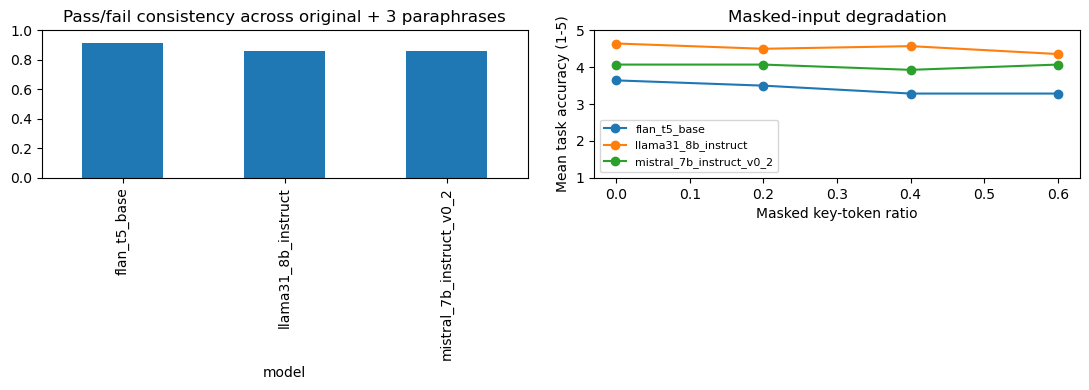

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
semantic_df.plot.bar(x='model', y='semantic_robustness', ylim=(0, 1), legend=False, ax=axes[0], title='Pass/fail consistency across original + 3 paraphrases')
for model, frame in mask_df.groupby('model'):
    axes[1].plot(frame['mask_ratio'], frame['mean_task_accuracy'], marker='o', label=model)
axes[1].set(title='Masked-input degradation', xlabel='Masked key-token ratio', ylabel='Mean task accuracy (1-5)', ylim=(1, 5))
axes[1].legend(fontsize=8)
plt.tight_layout()

In [4]:
performance = json.loads((ROOT / 'W04_System_Performance_Summary_v0.1.0.json').read_text(encoding='utf-8'))
performance_rows = []
for group in performance['groups']:
    if group['evaluation_family'] not in {'semantic_robustness', 'masked_input'}:
        continue
    e2e = group['latency_ms']['question_to_response_ms']
    ttft = group['latency_ms']['ttft_ms']
    gpu = group['resources']['gpu_device_memory_used_peak_mib']
    performance_rows.append({
        'model': group['candidate_model_key'], 'family': group['evaluation_family'],
        'n': group['row_count'], 'e2e_p50_ms': e2e['p50'], 'e2e_p95_ms': e2e['p95'],
        'ttft_p50_ms': ttft['p50'], 'gpu_peak_max_mib': gpu['max'],
    })
display(pd.DataFrame(performance_rows))

,model,family,n,e2e_p50_ms,e2e_p95_ms,ttft_p50_ms,gpu_peak_max_mib
0,flan_t5_base,semantic_robustness,140,647.110247,887.258738,88.733153,1393.0
1,llama31_8b_instruct,semantic_robustness,140,2023.022249,2992.488185,106.725852,15881.0
2,mistral_7b_instruct_v0_2,semantic_robustness,140,2135.844236,4565.291206,98.168179,14371.0


## Interpretation guardrail

A high consistency score can mean stable failure as well as stable success; therefore stable-pass and stable-fail counts are always shown separately. Mask curves describe synthetic product-context proxies on one A40 configuration, not deployed InGen products.